In [43]:
import pandas as pd
import numpy as np
import re
import ast

In [44]:
df = pd.read_csv("data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5600, 31)


In [45]:
print("Columns:")
print(df.columns.tolist())

Columns:
['candidate_id', 'target_role', 'education_level', 'education_relevance', 'experience_years', 'experience_relevance', 'common_skill_coverage', 'skill_gap_count', 'project_count', 'project_quality_score', 'project_relevance_score', 'project_depth_score', 'project_diversity_score', 'github_activity_score', 'live_project_count', 'portfolio_completeness_score', 'portfolio_design_score', 'portfolio_content_score', 'portfolio_evidence_score', 'technical_evidence_score', 'soft_skill_evidence_score', 'github_available', 'deployment_available', 'role_fit_score', 'portfolio_score', 'job_ready', 'shortlisted', 'hired', 'successful_candidate', 'data_origin', 'split']


In [46]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,candidate_id,target_role,education_level,education_relevance,experience_years,experience_relevance,common_skill_coverage,skill_gap_count,project_count,project_quality_score,...,github_available,deployment_available,role_fit_score,portfolio_score,job_ready,shortlisted,hired,successful_candidate,data_origin,split
0,CAND000001,AI Engineer,MTech,64,0.3,75,59,6,3,67,...,No,Yes,69,35,No,No,No,No,original,train
1,CAND000002,AI Engineer,BSc,15,3.7,68,100,0,3,90,...,Yes,Yes,66,76,No,No,No,No,original,validation
2,CAND000003,AI Engineer,BTech,54,3.8,63,100,2,4,67,...,Yes,Yes,77,66,Yes,Yes,No,No,original,validation
3,CAND000004,AI Engineer,MSc,90,2.8,66,75,1,0,57,...,Yes,Yes,83,61,Yes,No,No,No,original,test
4,CAND000005,AI Engineer,BSc,89,0.4,62,95,2,1,30,...,No,Yes,84,52,Yes,No,No,No,original,train


In [47]:
print("\nData types:")
print(df.dtypes)


Data types:
candidate_id                     object
target_role                      object
education_level                  object
education_relevance               int64
experience_years                float64
experience_relevance              int64
common_skill_coverage             int64
skill_gap_count                   int64
project_count                     int64
project_quality_score             int64
project_relevance_score           int64
project_depth_score               int64
project_diversity_score           int64
github_activity_score             int64
live_project_count                int64
portfolio_completeness_score      int64
portfolio_design_score            int64
portfolio_content_score           int64
portfolio_evidence_score          int64
technical_evidence_score          int64
soft_skill_evidence_score         int64
github_available                 object
deployment_available             object
role_fit_score                    int64
portfolio_score            

In [48]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
candidate_id                    0
target_role                     0
education_level                 0
education_relevance             0
experience_years                0
experience_relevance            0
common_skill_coverage           0
skill_gap_count                 0
project_count                   0
project_quality_score           0
project_relevance_score         0
project_depth_score             0
project_diversity_score         0
github_activity_score           0
live_project_count              0
portfolio_completeness_score    0
portfolio_design_score          0
portfolio_content_score         0
portfolio_evidence_score        0
technical_evidence_score        0
soft_skill_evidence_score       0
github_available                0
deployment_available            0
role_fit_score                  0
portfolio_score                 0
job_ready                       0
shortlisted                     0
hired                           0
successful_candidate           

In [49]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [50]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns.tolist())

['candidate_id', 'target_role', 'education_level', 'education_relevance', 'experience_years', 'experience_relevance', 'common_skill_coverage', 'skill_gap_count', 'project_count', 'project_quality_score', 'project_relevance_score', 'project_depth_score', 'project_diversity_score', 'github_activity_score', 'live_project_count', 'portfolio_completeness_score', 'portfolio_design_score', 'portfolio_content_score', 'portfolio_evidence_score', 'technical_evidence_score', 'soft_skill_evidence_score', 'github_available', 'deployment_available', 'role_fit_score', 'portfolio_score', 'job_ready', 'shortlisted', 'hired', 'successful_candidate', 'data_origin', 'split']


In [51]:
def clean_text(value):
    if pd.isna(value):
        return ""

    value = str(value)
    value = re.sub(r"\s+", " ", value)
    value = value.strip()

    return value

In [52]:
text_columns = df.select_dtypes(include=["object"]).columns

for column in text_columns:
    df[column] = df[column].apply(clean_text)

In [53]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)

No missing values found.


In [54]:
empty_values = {}

for column in df.columns:
    count = (df[column] == "").sum()
    if count > 0:
        empty_values[column] = count

print(empty_values)

{}


In [55]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nNumeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nText columns:")
print(df.select_dtypes(include="object").columns.tolist())

Rows: 5600
Columns: 31

Numeric columns:
['education_relevance', 'experience_years', 'experience_relevance', 'common_skill_coverage', 'skill_gap_count', 'project_count', 'project_quality_score', 'project_relevance_score', 'project_depth_score', 'project_diversity_score', 'github_activity_score', 'live_project_count', 'portfolio_completeness_score', 'portfolio_design_score', 'portfolio_content_score', 'portfolio_evidence_score', 'technical_evidence_score', 'soft_skill_evidence_score', 'role_fit_score', 'portfolio_score']

Text columns:
['candidate_id', 'target_role', 'education_level', 'github_available', 'deployment_available', 'job_ready', 'shortlisted', 'hired', 'successful_candidate', 'data_origin', 'split']


In [56]:
categorical_columns = [
    "target_role",
    "education_level",
    "github_available",
    "deployment_available",
    "job_ready",
    "shortlisted",
    "hired",
    "successful_candidate",
    "data_origin",
    "split"
]

for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
    )

# normalisation

In [57]:
binary_columns = [
    "github_available",
    "deployment_available",
    "job_ready",
    "shortlisted",
    "hired",
    "successful_candidate"
]

for column in binary_columns:
    df_clean[column] = (
        df_clean[column]
        .str.strip()
        .str.lower()
    )

print(df_clean[binary_columns].head())

  github_available deployment_available job_ready shortlisted hired  \
0                0                    1         0           0     0   
1                1                    1         0           0     0   
2                1                    1         1           1     0   
3                1                    1         1           0     0   
4                0                    1         1           0     0   

  successful_candidate  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


In [58]:
binary_mapping = {
    "yes": 1,
    "no": 0
}

for column in binary_columns:
    df_clean[column] = df_clean[column].map(binary_mapping)

print(df_clean[binary_columns].head())

   github_available  deployment_available  job_ready  shortlisted  hired  \
0               NaN                   NaN        NaN          NaN    NaN   
1               NaN                   NaN        NaN          NaN    NaN   
2               NaN                   NaN        NaN          NaN    NaN   
3               NaN                   NaN        NaN          NaN    NaN   
4               NaN                   NaN        NaN          NaN    NaN   

   successful_candidate  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  


In [59]:
numeric_columns = [
    "education_relevance",
    "experience_years",
    "experience_relevance",
    "common_skill_coverage",
    "skill_gap_count",
    "project_count",
    "project_quality_score",
    "project_relevance_score",
    "project_depth_score",
    "project_diversity_score",
    "github_activity_score",
    "live_project_count",
    "portfolio_completeness_score",
    "portfolio_design_score",
    "portfolio_content_score",
    "portfolio_evidence_score",
    "technical_evidence_score",
    "soft_skill_evidence_score",
    "role_fit_score",
    "portfolio_score"
]

print(df_clean[numeric_columns].dtypes)

education_relevance               int64
experience_years                float64
experience_relevance              int64
common_skill_coverage             int64
skill_gap_count                   int64
project_count                     int64
project_quality_score             int64
project_relevance_score           int64
project_depth_score               int64
project_diversity_score           int64
github_activity_score             int64
live_project_count                int64
portfolio_completeness_score      int64
portfolio_design_score            int64
portfolio_content_score           int64
portfolio_evidence_score          int64
technical_evidence_score          int64
soft_skill_evidence_score         int64
role_fit_score                    int64
portfolio_score                   int64
dtype: object


In [60]:
print(df_clean["target_role"].value_counts())
print(df_clean["education_level"].value_counts())
print(df_clean["split"].value_counts())

target_role
AI Engineer                  400
BI Analyst                   400
Backend Developer            400
Business Analyst             400
Cloud Engineer               400
Cybersecurity Analyst        400
Data Analyst                 400
Data Engineer                400
Data Scientist               400
DevOps Engineer              400
Frontend Developer           400
Full Stack Developer         400
Machine Learning Engineer    400
Software Developer           400
Name: count, dtype: int64
education_level
BTech      1400
BE          977
MSc         649
MCA         573
BSc         459
MTech       431
MBA         397
BCA         297
BBA         263
Diploma      90
PhD          64
Name: count, dtype: int64
split
train         4492
validation     554
test           554
Name: count, dtype: int64


In [61]:
target_columns = [
    "job_ready",
    "shortlisted",
    "hired",
    "successful_candidate"
]

for column in target_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts())
    print(df_clean[column].value_counts(normalize=True))


job_ready
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

shortlisted
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

hired
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

successful_candidate
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)


In [62]:
df_clean.to_csv(
    "portfolio_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")
print("Shape:", df_clean.shape)

Preprocessed dataset saved successfully!
Shape: (5600, 31)


In [63]:
import matplotlib.pyplot as plt

numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical columns:", len(numeric_columns))
print("\nNumerical columns:")
print(numeric_columns.tolist())

Number of numerical columns: 26

Numerical columns:
['education_relevance', 'experience_years', 'experience_relevance', 'common_skill_coverage', 'skill_gap_count', 'project_count', 'project_quality_score', 'project_relevance_score', 'project_depth_score', 'project_diversity_score', 'github_activity_score', 'live_project_count', 'portfolio_completeness_score', 'portfolio_design_score', 'portfolio_content_score', 'portfolio_evidence_score', 'technical_evidence_score', 'soft_skill_evidence_score', 'github_available', 'deployment_available', 'role_fit_score', 'portfolio_score', 'job_ready', 'shortlisted', 'hired', 'successful_candidate']


In [64]:
df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
education_relevance,5600.0,65.681786,19.168568,3.0,53.0,69.0,81.0,100.0
experience_years,5600.0,2.096661,1.541644,0.0,1.0,1.7,2.8,13.2
experience_relevance,5600.0,67.975000,15.930924,9.0,57.0,68.0,79.0,100.0
common_skill_coverage,5600.0,80.510536,16.311649,7.0,71.0,83.0,94.0,100.0
skill_gap_count,5600.0,2.095536,1.655544,0.0,1.0,2.0,3.0,10.0
project_count,5600.0,3.329821,1.624503,0.0,2.0,3.0,4.0,10.0
project_quality_score,5600.0,64.610357,15.610616,4.0,54.0,64.0,75.0,100.0
project_relevance_score,5600.0,77.093929,13.984635,4.0,68.0,78.0,87.0,100.0
project_depth_score,5600.0,55.697679,16.453158,0.0,45.0,56.0,66.0,100.0
project_diversity_score,5600.0,57.601786,16.601493,0.0,47.0,57.0,69.0,100.0


In [65]:
target_columns = [
    "job_ready",
    "shortlisted",
    "hired",
    "successful_candidate"
]

for column in target_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts())


job_ready
Series([], Name: count, dtype: int64)

shortlisted
Series([], Name: count, dtype: int64)

hired
Series([], Name: count, dtype: int64)

successful_candidate
Series([], Name: count, dtype: int64)


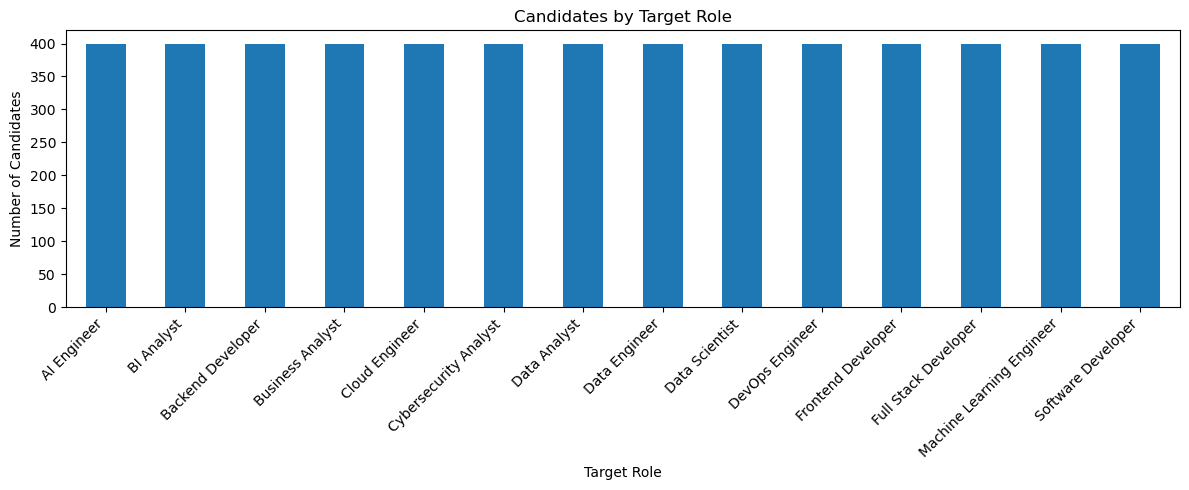

In [66]:
df_clean["target_role"].value_counts().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Candidates by Target Role")
plt.xlabel("Target Role")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

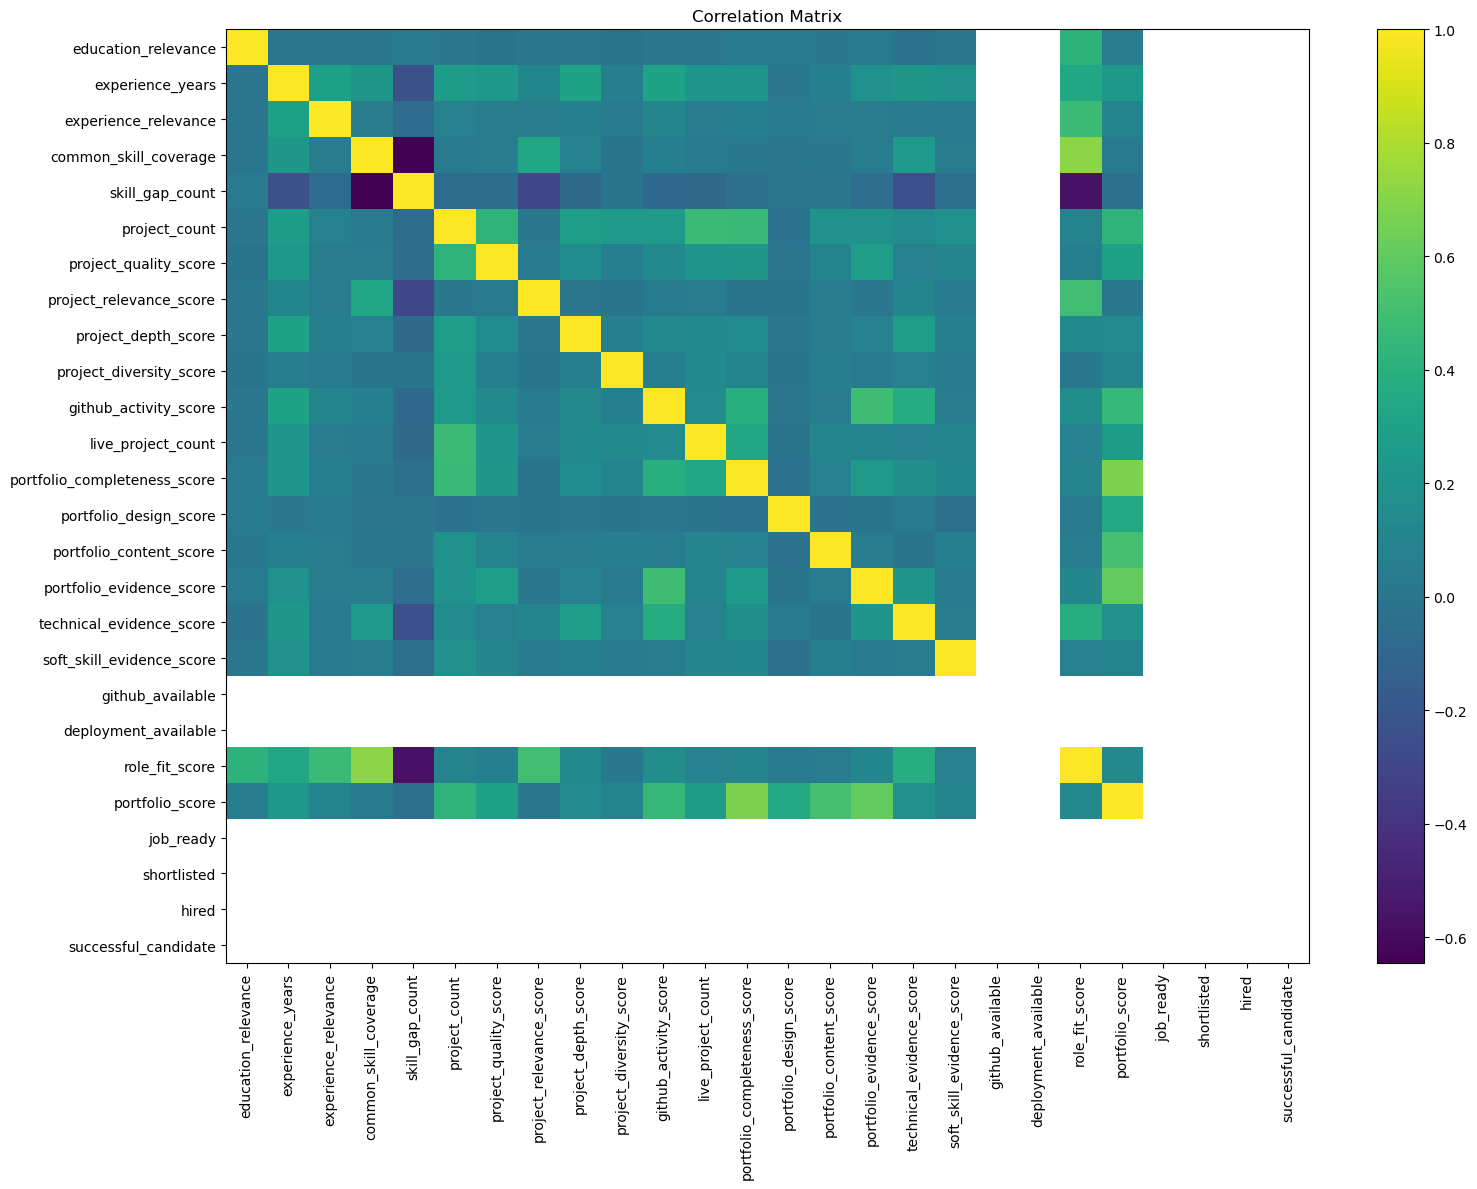

In [67]:
correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(16, 12))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [68]:
print("Total rows:", len(df_clean))

print("\nRole distribution:")
print(df_clean["target_role"].value_counts().sort_index())

print("\nSplit distribution:")
print(df_clean["split"].value_counts())

print("\nRole × Split:")
print(
    pd.crosstab(
        df_clean["target_role"],
        df_clean["split"]
    )
)

Total rows: 5600

Role distribution:
target_role
AI Engineer                  400
BI Analyst                   400
Backend Developer            400
Business Analyst             400
Cloud Engineer               400
Cybersecurity Analyst        400
Data Analyst                 400
Data Engineer                400
Data Scientist               400
DevOps Engineer              400
Frontend Developer           400
Full Stack Developer         400
Machine Learning Engineer    400
Software Developer           400
Name: count, dtype: int64

Split distribution:
split
train         4492
validation     554
test           554
Name: count, dtype: int64

Role × Split:
split                      test  train  validation
target_role                                       
AI Engineer                  40    320          40
BI Analyst                   40    320          40
Backend Developer            40    320          40
Business Analyst             40    320          40
Cloud Engineer               40 

# feature engineering

In [69]:
TARGET = "job_ready"

print("Target variable:", TARGET)

print("\nTarget distribution:")
print(df_clean[TARGET].value_counts())

print("\nTarget distribution (%):")
print(
    df_clean[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target variable: job_ready

Target distribution:
Series([], Name: count, dtype: int64)

Target distribution (%):
Series([], Name: proportion, dtype: float64)


In [70]:
candidate_features = [
    "target_role",
    "education_level",
    "education_relevance",
    "experience_years",
    "experience_relevance",
    "common_skill_coverage",
    "skill_gap_count",
    "project_count",
    "project_quality_score",
    "project_relevance_score",
    "project_depth_score",
    "project_diversity_score",
    "github_activity_score",
    "live_project_count",
    "portfolio_completeness_score",
    "portfolio_design_score",
    "portfolio_content_score",
    "portfolio_evidence_score",
    "technical_evidence_score",
    "soft_skill_evidence_score",
    "github_available",
    "deployment_available"
]

print("Number of candidate features:", len(candidate_features))

print("\nCandidate features:")
for feature in candidate_features:
    print("-", feature)

Number of candidate features: 22

Candidate features:
- target_role
- education_level
- education_relevance
- experience_years
- experience_relevance
- common_skill_coverage
- skill_gap_count
- project_count
- project_quality_score
- project_relevance_score
- project_depth_score
- project_diversity_score
- github_activity_score
- live_project_count
- portfolio_completeness_score
- portfolio_design_score
- portfolio_content_score
- portfolio_evidence_score
- technical_evidence_score
- soft_skill_evidence_score
- github_available
- deployment_available


In [71]:
outcome_columns = [
    "job_ready",
    "shortlisted",
    "hired",
    "successful_candidate"
]

print("Outcome columns excluded from features:")
print(outcome_columns)

Outcome columns excluded from features:
['job_ready', 'shortlisted', 'hired', 'successful_candidate']


In [72]:
X = df_clean[candidate_features].copy()
y = df_clean[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny distribution:")
print(y.value_counts())

X shape: (5600, 22)
y shape: (5600,)

X columns:
['target_role', 'education_level', 'education_relevance', 'experience_years', 'experience_relevance', 'common_skill_coverage', 'skill_gap_count', 'project_count', 'project_quality_score', 'project_relevance_score', 'project_depth_score', 'project_diversity_score', 'github_activity_score', 'live_project_count', 'portfolio_completeness_score', 'portfolio_design_score', 'portfolio_content_score', 'portfolio_evidence_score', 'technical_evidence_score', 'soft_skill_evidence_score', 'github_available', 'deployment_available']

y distribution:
Series([], Name: count, dtype: int64)


In [73]:
X.to_csv("X_features.csv", index=False)
y.to_csv("y_target.csv", index=False)

print("Features and target saved successfully.")

Features and target saved successfully.
